# Notebook to demo point near point analysis using QR.

In [1]:
import geofunctions as S
import geopandas as gp
import pyspark.sql.functions as F
from pyspark.sql import Window

### Create LHS points.

In [2]:
lhs = (
    spark.range(20)
    .withColumnRenamed("id", "lid")
    .withColumn("lhs", S.st_point(F.rand() * 100, F.rand() * 100))
)

### Create RHS points.

In [3]:
rhs = (
    spark.range(20)
    .withColumnRenamed("id", "rid")
    .withColumn("rhs", S.st_point(F.rand() * 100, F.rand() * 100))
)

### Define search distance and QR cell size.

In [4]:
dist = 10.0
cell = dist * 4.0

### Create implicit spatial index.

In [5]:
lhs_qr = lhs.withColumn("lqr", F.explode(S.qr_envp("lhs", cell, dist)))
rhs_qr = rhs.withColumn("rqr", F.explode(S.qr_envp("rhs", cell, dist)))

### Define window to find nearest row.

In [6]:
over = Window.partitionBy("lid").orderBy("dist")

In [7]:
res = (
    lhs_qr.join(rhs_qr, lhs_qr.lqr.qr == rhs_qr.rqr.qr)
    # Check lower left qr intersection :-)
    .filter(S.qr_intersect("lqr", "rqr", cell))
    .drop("lqr", "rqr")
    # Calc and filter "far" points.
    .withColumn("dist", S.st_distance("lhs", "rhs"))
    .filter(F.col("dist") < dist)
    .withColumn("rn", F.row_number().over(over))
    .filter("rn==1")
    .drop("rn")
    .select("lid", "rid", S.st_polyline("lhs", "rhs").alias("line"), "dist")
)

### Let's plot the results.

What is the nearest green point (rhs) to a red point (lhs) within search distance (yellow) ?

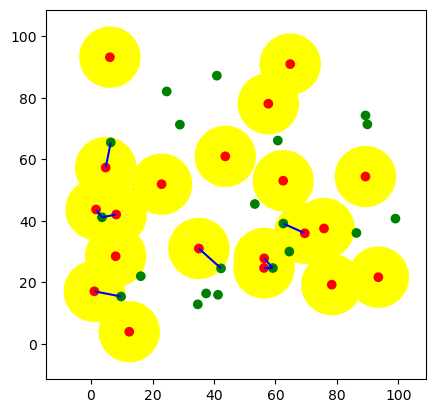

In [8]:
df1 = lhs.select(F.col("lhs").alias("geometry"), F.lit("red").alias("color"))
df2 = rhs.select(F.col("rhs").alias("geometry"), F.lit("green").alias("color"))
df3 = res.select(F.col("line").alias("geometry"), F.lit("blue").alias("color"))
df4 = lhs.select(S.st_buffer("lhs", dist).alias("geometry"), F.lit("yellow").alias("color"))

pdf = df1.unionAll(df2).unionAll(df3).unionAll(df4).toPandas()
pdf.geometry = gp.GeoSeries.from_wkb(pdf.geometry)
gdf = gp.GeoDataFrame(pdf)
_ = gdf.plot(color=pdf.color)